In [4]:
import pandas as pd

In [6]:
# 1. Load the dataset
df = pd.read_csv('../data/gym_churn_us.csv')

In [7]:
# 2. Standardize Column Names
# Some of your columns have capital letters (Near_Location) and some don't (gender). 
# This makes them all lowercase so you don't have to memorize the exact casing later.
df.columns = df.columns.str.lower()

In [8]:
# 3. Quick Check for Missing Values
# Even though the screenshot looks clean, we always double-check.
print("--- Missing Values Check ---")
print(df.isnull().sum())

--- Missing Values Check ---
gender                               0
near_location                        0
partner                              0
promo_friends                        0
phone                                0
contract_period                      0
group_visits                         0
age                                  0
avg_additional_charges_total         0
month_to_end_contract                0
lifetime                             0
avg_class_frequency_total            0
avg_class_frequency_current_month    0
churn                                0
dtype: int64


In [9]:
# 4. Final Look
print(f"\nDataset ready! Shape: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())


Dataset ready! Shape: 4000 rows and 14 columns


,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Set the visual style for the charts
sns.set_theme(style="whitegrid")

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_26424\1921292910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', palette='Set2')


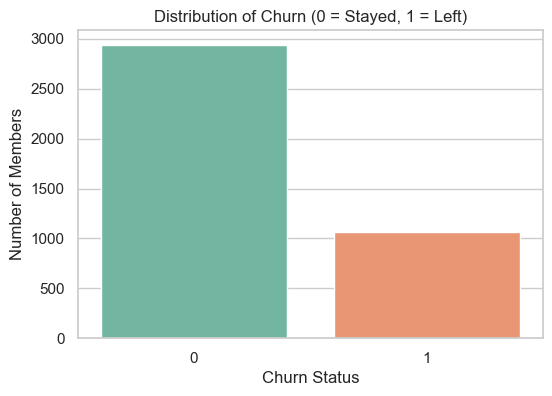

In [12]:
# 1. Check the Class Imbalance (Target Variable)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', palette='Set2')
plt.title('Distribution of Churn (0 = Stayed, 1 = Left)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Members')
plt.show()

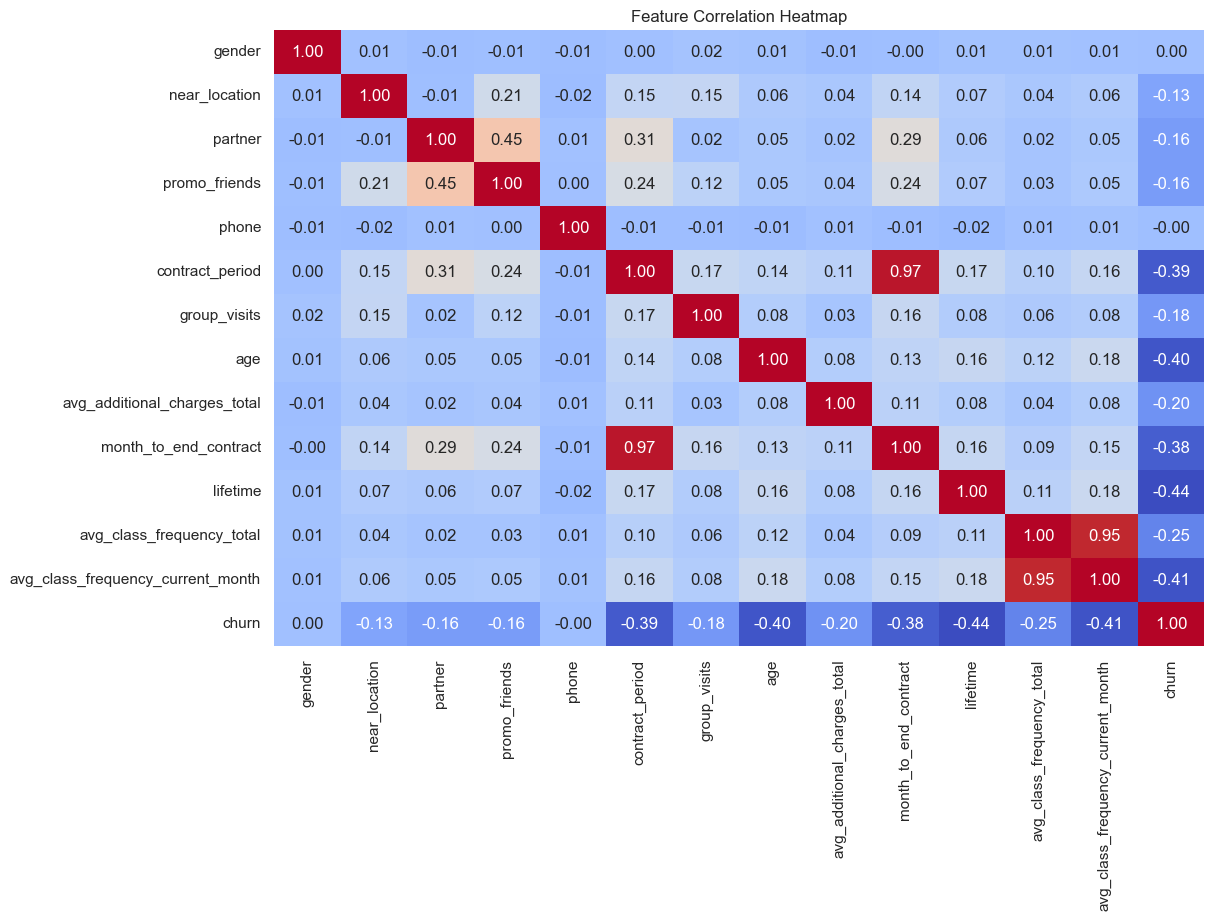

In [13]:
# 2. Correlation Heatmap (The "Cheat Sheet")
# This shows exactly which features are mathematically linked to churn
plt.figure(figsize=(12, 8))
# Compute the correlation matrix
corr_matrix = df.corr()
# Plot it using a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
plt.title('Feature Correlation Heatmap')
plt.show()

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_26424\1940343031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='contract_period', y='churn', palette='viridis', errorbar=None)


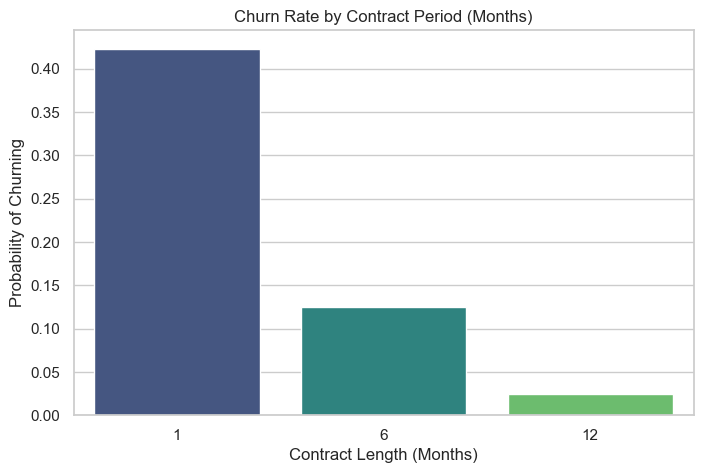

In [14]:
# 3. Business Insight: Contract Period vs. Churn
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='contract_period', y='churn', palette='viridis', errorbar=None)
plt.title('Churn Rate by Contract Period (Months)')
plt.xlabel('Contract Length (Months)')
plt.ylabel('Probability of Churning')
plt.show()

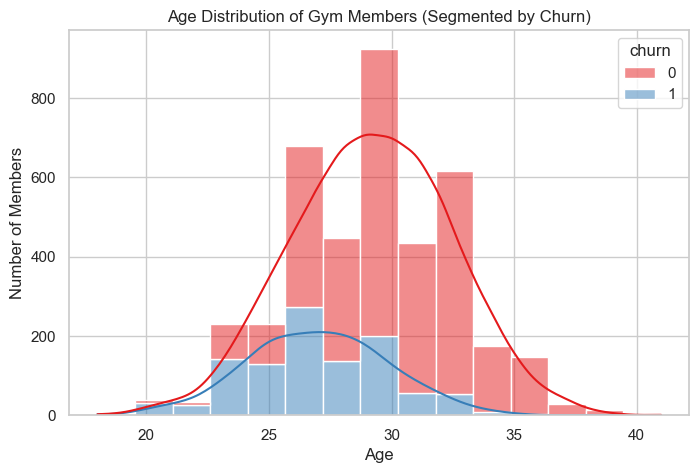

In [15]:
# 4. Demographic Insight: Age vs. Churn
# Are older or younger members more likely to quit?
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='churn', multiple='stack', bins=15, palette='Set1', kde=True)
plt.title('Age Distribution of Gym Members (Segmented by Churn)')
plt.xlabel('Age')
plt.ylabel('Number of Members')
plt.show()

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_26424\1507497412.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='lifetime', palette='Set3')


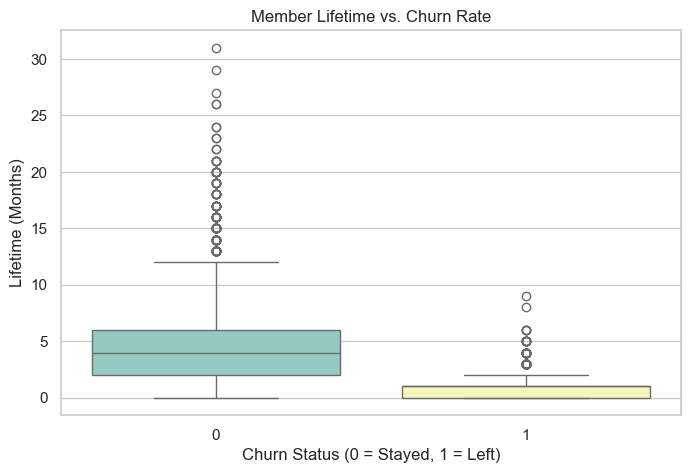

In [16]:
# 5. The Loyalty Factor: Lifetime (Months as a Member)
# Do people quit right away, or after years of loyalty?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='lifetime', palette='Set3')
plt.title('Member Lifetime vs. Churn Rate')
plt.xlabel('Churn Status (0 = Stayed, 1 = Left)')
plt.ylabel('Lifetime (Months)')
plt.show()

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_26424\2017110464.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='group_visits', y='churn', ax=axes[0], palette='pastel', errorbar=None)
C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_26424\2017110464.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='promo_friends', y='churn', ax=axes[1], palette='pastel', errorbar=None)


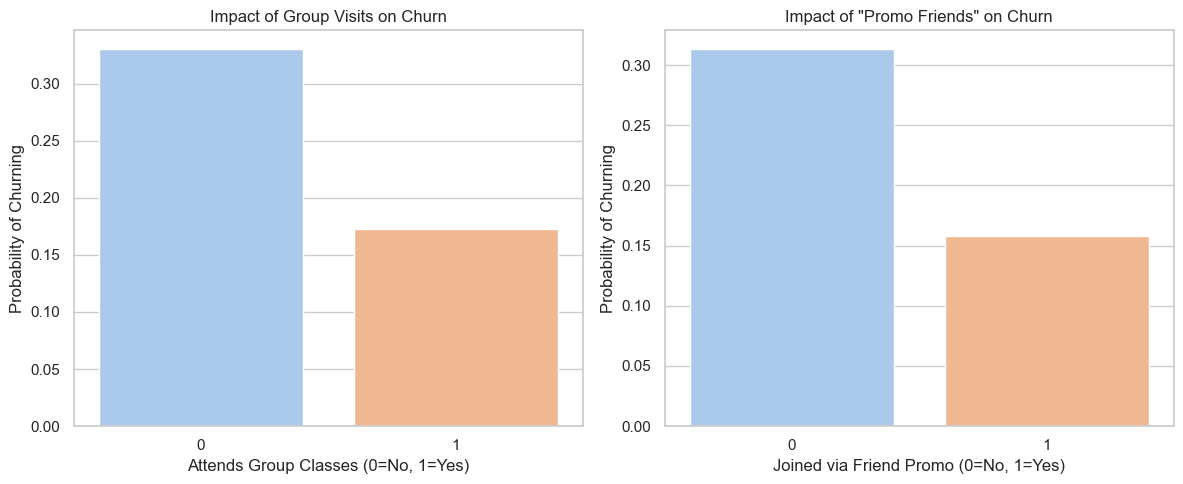

In [18]:
# 6. The Social Factor: Group Visits & Promo Friends
# Does working out with friends or in groups reduce churn?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='group_visits', y='churn', ax=axes[0], palette='pastel', errorbar=None)
axes[0].set_title('Impact of Group Visits on Churn')
axes[0].set_xlabel('Attends Group Classes (0=No, 1=Yes)')
axes[0].set_ylabel('Probability of Churning')

sns.barplot(data=df, x='promo_friends', y='churn', ax=axes[1], palette='pastel', errorbar=None)
axes[1].set_title('Impact of "Promo Friends" on Churn')
axes[1].set_xlabel('Joined via Friend Promo (0=No, 1=Yes)')
axes[1].set_ylabel('Probability of Churning')

plt.tight_layout()
plt.show()

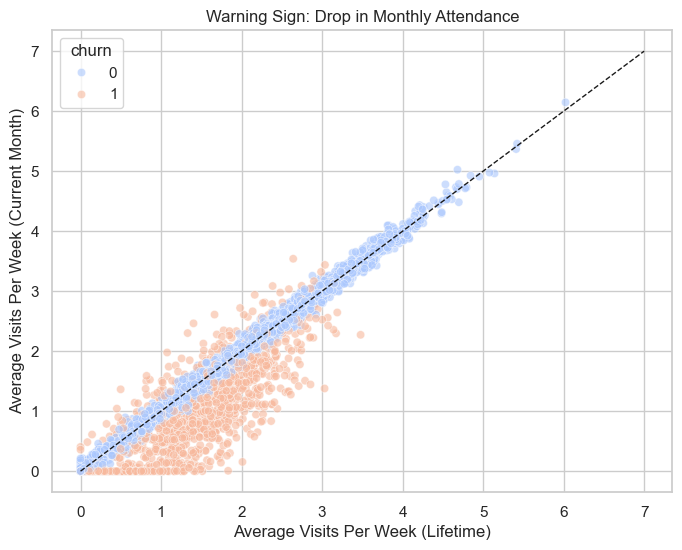

In [19]:
# 7. Behavioral Drop-off: The "Red Flag" Metric
# Comparing their historical attendance vs. this month's attendance
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='avg_class_frequency_total', 
                y='avg_class_frequency_current_month', 
                hue='churn', alpha=0.6, palette='coolwarm')
plt.title('Warning Sign: Drop in Monthly Attendance')
plt.xlabel('Average Visits Per Week (Lifetime)')
plt.ylabel('Average Visits Per Week (Current Month)')
# Adding a reference line where historical attendance equals current attendance
plt.plot([0, 7], [0, 7], 'k--', linewidth=1) 
plt.show()

In [26]:
# Save the perfectly clean, pre-SMOTE data to a new CSV file
# index=False is crucial so Pandas doesn't accidentally save the row numbers as a new column!
df.to_csv('../data/cleaned_gym_data.csv', index=False)
print("Clean data saved successfully!")

Clean data saved successfully!
